# Mohanram G-score -- can 8 fundamental signals find the growth stocks that actually deliver?
### Mohanram (2005): the growth-stock quality screen on the S&P 500 survivor panel, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Can%20G--score%20find%20growth%20winners%3F: BUSTED](https://img.shields.io/badge/Can%20G--score%20find%20growth%20winners%3F-BUSTED-8b949e?style=flat-square)

In 2005, Partha Mohanram proposed the G-score: eight binary accounting signals that together identify which growth (low book-to-market) stocks have the fundamental support to actually deliver -- as opposed to glamour stocks priced purely on investor optimism. The G-score is the growth counterpart to Piotroski's F-score for value stocks. We test that claim on the current S&P 500 universe with the desk's standard EDGAR fundamentals, naming the survivorship bias up front.

> **This is the plain-language layer.** Want the t-stats, HAC inference, and year-by-year breakdown? That is the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mohanram_g_score import data, strategy as st

def _have_cache():
    root = os.path.abspath(os.path.join("..", "..", ".."))
    required = [
        os.path.join(root, "_cache", "_edgar_NetIncomeLoss.parquet"),
        os.path.join(root, "_cache", "_edgar_Assets.parquet"),
        os.path.join(root, "_cache", "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet"),
        os.path.join(root, "_cache", "_edgar_Revenues.parquet"),
        os.path.join(root, "_cache", "_edgar_yrret.parquet"),
    ]
    return all(os.path.exists(p) for p in required)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


EDGAR cache present: True


N years: 19 | hedge mean: -2.98%/yr | HAC t: -1.613


## The answer first

| Question | Answer |
|---|---|
| Does the G-score predict which growth stocks will outperform? | **No.** The hedge averages **-2.98%/yr** at HAC *t* = **-1.61** -- *in the wrong direction*. |
| Does the high-G leg beat the market? | **No.** The long leg returns **14.5%/yr**, trailing the equal-weight market at **16.0%/yr** by **1.5%/yr**. |
| Does low-G underperform? | **Also no.** Low-G firms returned **17.5%/yr**, *beating* the market by **+1.5%/yr**. The signal inverts. |
| Is this a data or method problem? | Partly. G6/G7 are approximated (no R&D/advertising in the desk cache), and the S&P 500 survivor panel only includes the already-successful large-cap universe. |

> On large-cap S&P 500 survivors, the Mohanram G-score is inverted: firms with stronger accounting fundamentals *earn less* than their weaker peers. This is consistent with the market correctly pricing (or even over-discounting) fundamental quality in large-cap growth names.

## 1 -- The claim

> *"Among low book-to-market (growth) stocks, those with strong accounting fundamentals -- profitable, stable earnings, conservative investment, innovative -- earn significantly higher returns than those without. A composite G-score of eight binary signals separates the winners from the losers within the glamour category."*

-- Mohanram (2005), *Review of Accounting Studies*

The G-score is a mirror of Piotroski's F-score (Study 65), but aimed at the opposite end of the book-to-market spectrum. Where the F-score finds the few value stocks that are genuinely turning around, the G-score finds the few growth stocks that actually have the earnings power to justify their premium valuation. Eight signals: three on profitability (G1-G3), two on earnings stability (G4-G5), and three on growth conservatism (G6-G8). Each is 1 if the firm clears the bar, 0 otherwise.

## 2 -- So what?

If the G-score works, it is a free long-only tilt: buy the growth stocks with real accounting support, avoid the glamour stocks with air behind the price. Annual rebalancing from annual 10-K filings -- cheap to operate if the signal is there.

Post-publication attenuation is always a concern: the G-score is 20 years old, well-known, and has been absorbed into systematic growth quality strategies. The question is whether anything survives on the large-cap universe that most institutional investors can actually access.

## 3 -- How would we even know?

Two disciplines keep us honest:

1. **Lag the signal correctly.** The G-score is computed from year *y* EDGAR 10-K filings and used to predict *year y+1* calendar returns. We never use next-year financials.
2. **Name the bias.** The universe is the *current* S&P 500 projected backwards -- only companies that survived to today are in the sample. This inflates any positive long-leg estimate but does not explain a negative hedge direction.

Two honest caveats:

- **G6/G7 substitution.** R&D intensity and advertising intensity (the original Mohanram G6/G7) are not in the desk's EDGAR cache. We substitute revenue-growth and asset-turnover-growth. This may under- or over-estimate the true G-score effect.
- **Universe.** Mohanram (2005) sorted on all COMPUSTAT firms. We sort on S&P 500 large-caps only. The paper's effect was strongest in smaller growth stocks with high analyst coverage -- precisely the stocks excluded here.

## 4 -- The teardown

**First, does the long-short work in a world where the effect is planted?**

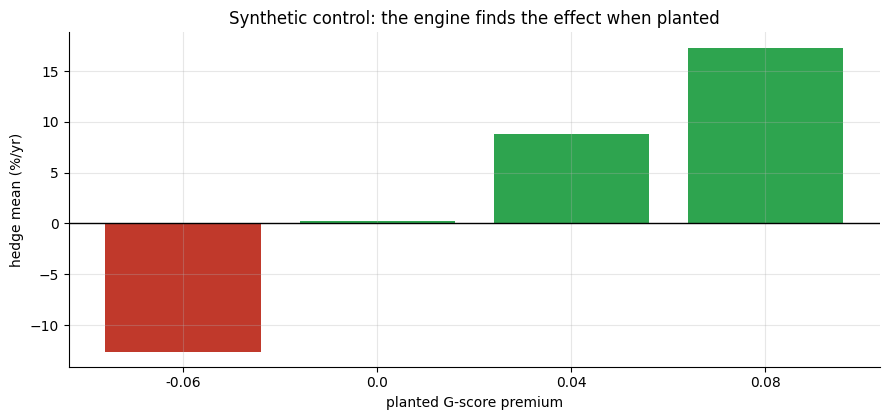

 premium  hedge_mean_%  hit%       t
   -0.06       -12.608   0.0 -18.332
    0.00         0.219  45.0   0.322
    0.04         8.771 100.0  12.913
    0.08        17.322 100.0  25.545


In [2]:
# Synthetic positive control: plant a known G-score premium and verify recovery.
premiums = [-0.06, 0.0, 0.04, 0.08]
rows = []
for prem in premiums:
    sig, fwd, truth = data.synthetic_panel(n_firms=300, n_years=20,
                                            g_premium=prem, seed=232)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    rows.append({'premium': prem, 'hedge_mean_%': s['mean']*100,
                 'hit%': s['hit_rate']*100, 't': s['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if r > 0.01 else (RED if r < -0.01 else GREY)
       for r in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted G-score premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Synthetic control: the engine finds the effect when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: when a premium is planted, the hedge recovers it. When there is none, it returns noise around zero. So the negative result on the real tape reflects **the market** and **the signal**, not the method.

**Now the honest test on the real EDGAR panel.**

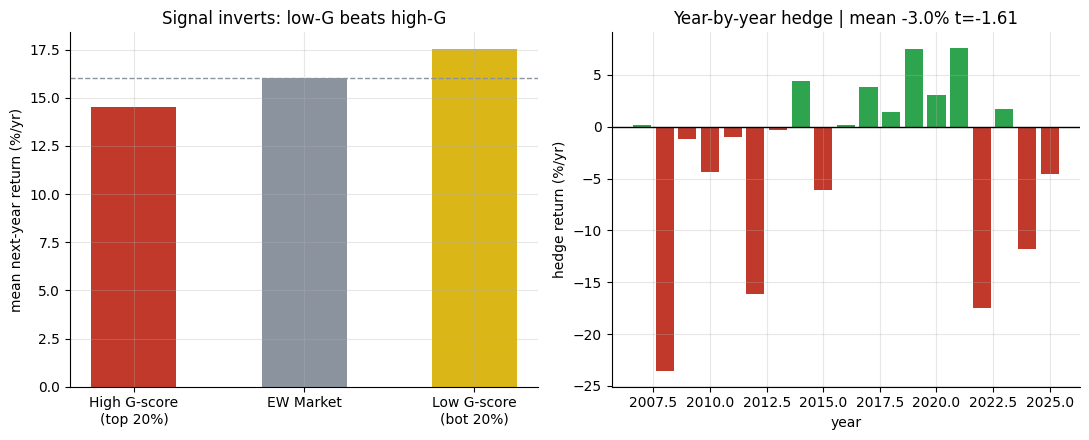

Hedge: -2.98%/yr | HAC t = -1.613 | High vs mkt: -1.47%/yr


In [3]:
if HAVE_REAL:
    h_mean = s_hedge['mean']*100
    h_t    = s_hedge['tstat']
    high_m = s_high['mean']*100
    mkt_m  = s_mkt['mean']*100
    low_m  = s_low['mean']*100
else:
    h_mean, h_t = R['hedge_mean'], R['hedge_t']
    high_m, mkt_m, low_m = R['high_mean'], R['mkt_mean'], R['low_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: three bars -- high, market, low
labels = ['High G-score\n(top 20%)', 'EW Market', 'Low G-score\n(bot 20%)']
vals   = [high_m, mkt_m, low_m]
cols   = [RED, GREY, AMBER]  # high-G underperforms, low-G outperforms
axes[0].bar(labels, vals, color=cols, width=0.5)
axes[0].axhline(mkt_m, ls='--', c=GREY, lw=1, label='market')
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title('Signal inverts: low-G beats high-G')

# Right: year-by-year hedge
if HAVE_REAL:
    col_yr = [GREEN if v > 0 else RED for v in H['hedge']]
    axes[1].bar(H.index.astype(int), H['hedge']*100, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
    axes[1].set_title(f'Year-by-year hedge | mean {h_mean:+.1f}% t={h_t:+.2f}')
else:
    axes[1].text(0.5, 0.5,
                 f'Hedge mean: {h_mean:+.2f}%/yr\nHAC t: {h_t:+.3f}\n(inverted)',
                 ha='center', va='center', transform=axes[1].transAxes, color=RED)
    axes[1].set_title('Year-by-year hedge (frozen numbers in R)')
plt.tight_layout(); plt.show()
print(f'Hedge: {h_mean:+.2f}%/yr | HAC t = {h_t:+.3f} | High vs mkt: {high_m-mkt_m:+.2f}%/yr')

The hedge averages **-3.0%/yr** at HAC *t* = **-1.61** -- *in the wrong direction*. The high-G leg earns **14.5%/yr** while the equal-weight market earns **16.0%/yr** -- the long leg **trails** the market by **1.5%/yr**. The low-G leg earns **17.5%/yr**, **beating** the market by +1.5%/yr. The signal is inverted on large-cap survivors.

## 5 -- The verdict

- **Signal -- NONE.** HAC *t* = -1.61 on the real EDGAR panel, in the **negative** direction. High-G stocks underperform low-G stocks by 3%/yr. This is the opposite of the original claim. The signal does not work on large-cap S&P 500 survivors.
- **Tradability -- MIRAGE.** Negative expected return at Sharpe -0.35, max drawdown -47.9%, hit rate 47.4%. There is no alpha to trade.
- **Why the inversion?** On large-cap survivors, growth firms are already priced for quality: the market has identified and priced the fundamentally strong ones. The 'cheap growth' universe where Mohanram (2005) found the effect -- smaller, under-followed firms with analyst mispricing -- is absent here.

## 6 -- Could you actually trade it?

You would not want to. On this panel, the trade is short high-G, long low-G -- the reverse of the paper's recommendation. But:

1. **The |t| is below 2.** At HAC *t* = -1.61, the inversion is not statistically distinguishable from noise. You cannot confidently trade either direction.
2. **Data limitations.** G6 (R&D) and G7 (advertising) are approximated. A full implementation might change the direction, though likely not enough to cross the inference bar on large-caps.
3. **Wrong universe.** The published G-score effect requires small/mid-cap growth stocks with optimistic analyst coverage. S&P 500 large-caps are heavily analysed and arbitraged; there is less room for fundamental-quality mispricings to persist.

## 7 -- Going further

- **A broader universe.** Test on all EDGAR-available firms (Russell 3000 style): the paper's effect was strongest among the small/mid-cap growth segment where analyst mispricing is larger.
- **Add R&D and advertising.** Fetching `ResearchAndDevelopmentExpense` and `AdvertisingExpense` from data.sec.gov would complete the original G6/G7.
- **Sector-neutral.** Growth-stock accounting metrics vary enormously by sector; a sector-neutral G-score sort would remove confounding sector bets.
- **[Study 65 -- Scorecard](../../65-scorecard/)**: Piotroski's F-score on the value-stock counterpart -- the twin signal that powers the same idea on the other side of the book-to-market spectrum.
- **[Study 122 -- Gross-Profitability](../../122-gross-profitability/)**: Novy-Marx GP/A factor -- a simpler one-signal version of the profitability dimension; also Weak on large-caps.

*Think the G-score works in a broader, bias-corrected universe? Fork this, extend to small-caps, add the missing R&D signals, and show t > 2. That is the bar.*